In [ ]:
import numpy as np                                            # np — общепринятый псевдоним
from numpy.random import default_rng                          # современный генератор (PCG64)
import matplotlib.pyplot as plt                               # для визуализации
import seaborn as sns                                         # стильная надстройка над Matplotlib
sns.set_theme(style="darkgrid")                               # включаем тёмную сетку
print("Библиотеки загружены!")

Библиотеки загружены!


In [ ]:
# АРИФМЕТИЧЕСКИЕ ОПЕРАЦИИ — ВЕКТОРИЗАЦИЯ
# Векторизация = операция над всеми элементами массива сразу
# NumPy делает это на скорости C, без единого Python-цикла
# В банке так пересчитывают DTI, применяют ставки, сравнивают платежи


# Данные 4 клиентов
income = np.array([50000, 75000, 40000, 120000])              # месячный доход, руб.
loan = np.array([300000, 500000, 200000, 800000])              # сумма кредита, руб.

# Поэлементное сложение
print("income + loan:", income + loan)                         # [350000, 575000, 240000, 920000]

# Умножение на скаляр → годовой доход
annual_income = income * 12                                    # каждый элемент умножается на 12
print("Годовой доход:", annual_income)

# Деление массивов → DTI (debt-to-income)
dti = loan / annual_income                                     # поэлементное деление
print("DTI:", dti)

# Сравнение → булева маска (True/False)
mask = income > 60000                                          # массив из True и False
print("Доход > 60k:", mask)                                    # [False, True, False, True]
print("Клиенты с доходом > 60k:", income[mask])               # применяем маску
# применение: так за секунду отбирают VIP-клиентов или рискованных заёмщиков

income + loan: [350000 575000 240000 920000]
Годовой доход: [ 600000  900000  480000 1440000]
DTI: [0.5        0.55555556 0.41666667 0.55555556]
Доход > 60k: [False  True False  True]
Клиенты с доходом > 60k: [ 75000 120000]


In [ ]:
# УСЛОВНАЯ ЛОГИКА БЕЗ ЦИКЛОВ
# Вместо медленного Python-цикла с if/elif/else NumPy даёт
# векторизованные np.where, np.select и np.piecewise


dti = np.array([0.2, 0.5, 0.6, 0.3, 0.15, 0.55, 0.48])      # DTI 7 клиентов

# np.where — простой условный выбор ---
# Сигнатура: np.where(условие, значение_если_True, значение_если_False)
decision = np.where(dti < 0.5, "Одобрить", "Отказ")
print("np.where:", decision)                                   # ['Одобрить', 'Отказ', 'Отказ', 'Одобрить', ...]

# np.select — множественные условия (аналог if/elif/else) ---
# Сигнатура: np.select([условие1, условие2, ...], [выбор1, выбор2, ...], default)
conditions = [
    dti < 0.3,                                                 # низкий риск
    (dti >= 0.3) & (dti < 0.5),                               # средний риск
    dti >= 0.5                                                 # высокий риск
]
choices = ["Одобрить", "На рассмотрении", "Отказ"]
decision3 = np.select(conditions, choices, default="Неизвестно")
print("np.select:", decision3)

# np.piecewise — кусочно-заданная функция ---
# Применяет разные функции к разным диапазонам значений
score = np.array([200, 450, 700, 850])                         # кредитный скоринг
result = np.piecewise(
    score,
    [score < 300, (score >= 300) & (score < 600), score >= 600],
    [lambda x: x * 0.5, lambda x: x * 1.0, lambda x: x * 1.2]
)
print("np.piecewise:", result)                                 # [100, 450, 840, 1020]
# применение:
# - np.where: одобрить/отказать по одному условию
# - np.select: многоуровневый скоринг
# - np.piecewise: расчёт ставки в зависимости от суммы кредита

np.where: ['Одобрить' 'Отказ' 'Отказ' 'Одобрить' 'Одобрить' 'Отказ' 'Одобрить']
np.select: ['Одобрить' 'Отказ' 'Отказ' 'На рассмотрении' 'Одобрить' 'Отказ'
 'На рассмотрении']
np.piecewise: [ 100  450  840 1020]


In [ ]:
# РАСШИРЕННЫЕ АГРЕГАЦИИ
# Кроме базовых sum/mean/std/min/max, NumPy даёт
# np.percentile и np.quantile для детального анализа распределений


scores = np.array([650, 720, 580, 690, 710, 640, 780])        # кредитные скоринги 7 клиентов

# Базовые агрегации (были в уроке 5.1, но напомним)
print("Средний скоринг:", scores.mean())                      # 681.43
print("Медиана:", np.median(scores))                           # 690.0

# перцентили и межквартильный размах (IQR)
q25 = np.percentile(scores, 25)                                # 25-й перцентиль
q75 = np.percentile(scores, 75)                                # 75-й перцентиль
iqr = q75 - q25                                                # IQR — мера разброса, устойчивая к выбросам
print(f"25-й перцентиль: {q25}\n75-й перцентиль: {q75}\nIQR: {iqr}")

# Квантили (аналогично percentile, но аргумент от 0 до 1)
print("Квантиль 0.25:", np.quantile(scores, 0.25))
print("Квантиль 0.75:", np.quantile(scores, 0.75))
# применение: IQR используют для поиска аномальных транзакций

Средний скоринг: 681.4285714285714
Медиана: 690.0
25-й перцентиль: 645.0
75-й перцентиль: 715.0
IQR: 70.0
Квантиль 0.25: 645.0
Квантиль 0.75: 715.0


In [ ]:
# АГРЕГАЦИИ ПО ОСЯМ (axis)
# axis=0 — сжимаем строки → результат по каждому столбцу
# axis=1 — сжимаем столбцы → результат по каждой строке

matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])                                 # матрица 3×3

print("Исходная матрица:\n", matrix)

# Сумма по столбцам (сжимаем строки, axis=0)
print("Сумма по столбцам (axis=0):", matrix.sum(axis=0))      # [12, 15, 18]

# Сумма по строкам (сжимаем столбцы, axis=1)
print("Сумма по строкам (axis=1):", matrix.sum(axis=1))        # [6, 15, 24]

# Общая сумма
print("Общая сумма:", matrix.sum())                             # 45

# Другие агрегации с axis
print("Среднее по столбцам:", matrix.mean(axis=0))             # [4., 5., 6.]
print("Максимум по строкам:", matrix.max(axis=1))              # [3, 6, 9]
# применение: sum(axis=0) по колонке «платежи» даст общую сумму платежей за каждый месяц

Исходная матрица:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
Сумма по столбцам (axis=0): [12 15 18]
Сумма по строкам (axis=1): [ 6 15 24]
Общая сумма: 45
Среднее по столбцам: [4. 5. 6.]
Максимум по строкам: [3 6 9]


In [ ]:
# анализ портфеля с трёхуровневым решением

rng = default_rng(42)                                          # создаём генератор случайных чисел с seed=42 (для воспроизводимости)
N = 100_000                                                    # 100 тысяч клиентов — размер портфеля

# Генерируем доходы клиентов из нормального распределения:
# среднее (loc) = 50 000 руб., стандартное отклонение (scale) = 20 000 руб.
income = rng.normal(50000, 20000, N)                           # массив доходов (форма (100000,))

# clip(a_min, a_max) обрезает значения: a_min=10000 — доход не может быть ниже 10 000 руб.
income = income.clip(10000, None)                              # всё, что меньше 10 000, становится 10 000

# Генерируем суммы кредитов:
# среднее = 200 000, разброс = 80 000
loan = rng.normal(200000, 80000, N)                            # массив кредитов

# clip(0, None) — сумма кредита не может быть отрицательной
loan = loan.clip(0, None)                                      # всё, что меньше 0, становится 0

# Векторизованный расчёт DTI (debt-to-income) — одной строкой для всех 100 000 клиентов!
# Формула: DTI = сумма_кредита / (доход * 12)
dti = loan / (income * 12)                                      # массив DTI той же длины

# Условия для трёхуровневого скоринга:
conditions = [
    dti < 0.3,                                                  # низкий риск: DTI < 0.3
    (dti >= 0.3) & (dti < 0.5),                                # средний риск: 0.3 ≤ DTI < 0.5
    dti >= 0.5                                                  # высокий риск: DTI ≥ 0.5
]

# Выборы (ответы) для каждого условия:
choices = ["Одобрить", "На рассмотрении", "Отказ"]

# np.select применяет правила: если условие 1 истинно — берётся choice 1,
# если нет — проверяется условие 2, и т.д. Если ни одно не подошло — default.
decisions = np.select(conditions, choices, default="Неизвестно")  # массив решений для всех клиентов

# Подсчитываем количество решений каждого типа
print(f"Всего заявок: {N:,}")
print(f"Одобрено: {np.sum(decisions == 'Одобрить'):,}")
print(f"На рассмотрении: {np.sum(decisions == 'На рассмотрении'):,}")
print(f"Отказ: {np.sum(decisions == 'Отказ'):,}")

Всего заявок: 100,000
Одобрено: 42,550
На рассмотрении: 32,935
Отказ: 24,515


In [ ]:
# ПОИСК ВЫБРОСОВ ЧЕРЕЗ IQR
# Выбросы — это потенциально мошеннические транзакции или ошибки
# Используем межквартильный размах для их обнаружения

Q1 = np.percentile(loan, 25)                                   # 25-й перцентиль
Q3 = np.percentile(loan, 75)                                   # 75-й перцентиль
IQR = Q3 - Q1                                                  # межквартильный размах
lower_bound = Q1 - 1.5 * IQR                                   # нижняя граница нормы
upper_bound = Q3 + 1.5 * IQR                                   # верхняя граница нормы

# Булева маска для выбросов
outliers = (loan < lower_bound) | (loan > upper_bound)         # True для аномальных сумм
n_outliers = outliers.sum()                                    # сколько выбросов
print(f"\nГраницы нормы: [{lower_bound:.0f}, {upper_bound:.0f}]")
print(f"Найдено {n_outliers} выбросов из {N} ({n_outliers/N:.2%})")
print("Примеры выбросов:", loan[outliers][:10])                # первые 10 аномалий


Границы нормы: [-16038, 416407]
Найдено 358 выбросов из 100000 (0.36%)
Примеры выбросов: [421214.86070203 471111.80049146 489465.04389993 421821.15387968
 419272.19859914 437168.58255003 424005.83643064 427784.65607774
 432587.92149916 427382.50371894]


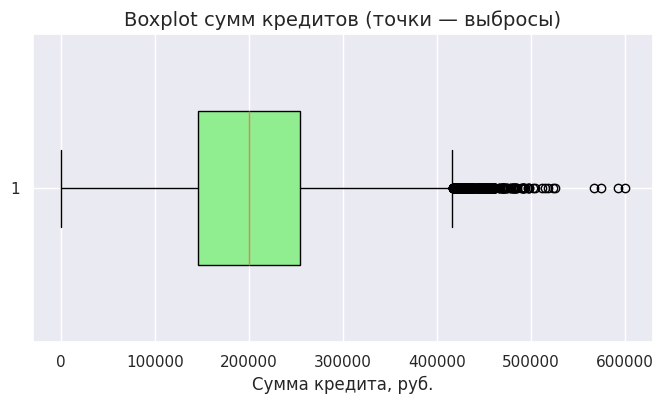

In [ ]:
#  boxplot для выбросов
plt.figure(figsize=(8, 4))
plt.boxplot(loan, vert=False, widths=0.5,
            patch_artist=True, boxprops=dict(facecolor='lightgreen'))
plt.title('Boxplot сумм кредитов (точки — выбросы)', fontsize=14)
plt.xlabel('Сумма кредита, руб.')
plt.show()
# Точки за «усами» — те самые выбросы, которые нашли выше

In [ ]:
#  ЛИНЕЙНАЯ АЛГЕБРА
# Кроме матричного умножения (было в уроке 5.1), NumPy даёт:
# - нормы векторов и матриц
# - ранг матрицы
# - решение линейных систем
# - собственные значения
# Всё это используется в ML-моделях и оптимизации


A = np.array([[1, 2],
              [3, 4]])                                         # матрица 2×2
b = np.array([5, 11])                                          # вектор правой части

# Нормы вектора
print("L2-норма (Евклидова):", np.linalg.norm(b, ord=2))      # √(5² + 11²)
print("L1-норма (Манхэттен):", np.linalg.norm(b, ord=1))      # |5| + |11|
print("L∞-норма (максимум модуля):", np.linalg.norm(b, ord=np.inf))

# Ранг матрицы
print("\nРанг A:", np.linalg.matrix_rank(A))                   # 2 — матрица полного ранга

# Решение линейной системы A @ x = b
x = np.linalg.solve(A, b)                                      # находим x
print("Решение Ax=b:", x)                                      # [2., 3.]
print("Проверка A @ x:", A @ x)                               # должно быть [5, 11]

# Собственные значения
eigenvalues = np.linalg.eigvals(A)                             # только собственные значения
print("\nСобственные значения A:", eigenvalues)

L2-норма (Евклидова): 12.083045973594572
L1-норма (Манхэттен): 16.0
L∞-норма (максимум модуля): 11.0

Ранг A: 2
Решение Ax=b: [1. 2.]
Проверка A @ x: [ 5. 11.]

Собственные значения A: [-0.37228132  5.37228132]


In [ ]:
# СРАВНЕНИЕ СКОРОСТИ: Python-цикл vs NumPy-сумма
# Ещё один замер, теперь для суммирования

data = rng.normal(0, 1, 1_000_000)                             # миллион чисел

# Python-цикл
import time
start = time.time()
total_py = 0
for x in data:
    total_py += x
py_time = time.time() - start
print(f"Python sum: {py_time:.4f} сек, результат: {total_py:.4f}")

# NumPy
start = time.time()
total_np = data.sum()
np_time = time.time() - start
print(f"NumPy sum:  {np_time:.4f} сек, результат: {total_np:.4f}")
print(f"NumPy быстрее в {py_time / np_time:.0f} раз!")

Python sum: 0.1946 сек, результат: 579.1667
NumPy sum:  0.0011 сек, результат: 579.1667
NumPy быстрее в 177 раз!


## 🎸 ТВОРЧЕСКОЕ ЗАДАНИЕ

1. Сгенерируй 50 000 кредитных заявок (доход — normal, кредит — normal).
2. Посчитай DTI.
3. Через `np.where` создай решение «Одобрить» / «Отказ» по порогу DTI=0.5.
4. Через `np.select` создай трёхуровневое решение (низкий/средний/высокий риск).
5. Найди выбросы по сумме кредита через IQR.
6. Реши линейную систему 3×3 через `np.linalg.solve`.